In [ ]:
import os
import string
import numpy as np
import matplotlib.pyplot as plt

def find_spectra_file(filename='spectra_archive.npz'):
    # Check a few common locations first
    checks = [
        os.path.join(os.getcwd(), filename),
        os.path.join(os.path.expanduser('~'), filename),
        os.path.join(os.path.expanduser('~'), 'Desktop', filename),
        os.path.join(os.path.expanduser('~'), 'Downloads', filename),
        os.path.join(os.path.expanduser('~'), 'Documents', filename)
    ]
    for p in checks:
        if os.path.exists(p):
            return p

    # Look for OneDrive folders under the user's home (common on Windows)
    home = os.path.expanduser('~')
    try:
        for entry in os.listdir(home):
            # Match folders named 'OneDrive' or starting with 'OneDrive' (e.g. 'OneDrive - Personal')
            if entry.lower().startswith('onedrive'):
                od = os.path.join(home, entry)
                candidates = [
                    os.path.join(od, filename),
                    os.path.join(od, 'Desktop', filename),
                    os.path.join(od, 'Documents', filename),
                ]
                for c in candidates:
                    if os.path.exists(c):
                        return c
    except Exception:
        pass

    # If not found, search all available drives (Windows) or root ('/') on Unix-like systems
    roots = []
    if os.name == 'nt':
        for letter in string.ascii_uppercase:
            root = f'{letter}:\\'
            if os.path.exists(root):
                roots.append(root)
    else:
        roots.append('/')

    for root in roots:
        for dirpath, dirnames, filenames in os.walk(root):
            if filename in filenames:
                return os.path.join(dirpath, filename)
    return None

# Try to find the file automatically
file_path = find_spectra_file('spectra_archive.npz')
if file_path is None:
    print('Could not find spectra_archive.npz automatically.')
    print('Place the file in this notebook folder or your Desktop/Downloads, or install it on a reachable drive.')
    raise FileNotFoundError('spectra_archive.npz not found')
else:
    print(f'Loading spectra from: {file_path}')
    data = np.load(file_path)
    print(data.files)  # List all arrays in the .npz file

keys = [
    "A2V_wl", "A2V_flux",
    "A6V_wl", "A6V_flux", "A9V_wl", "A9V_flux",
    "B1V_wl", "B1V_flux", "B6V_wl", "B6V_flux",
    "F0V_wl", "F0V_flux", "F5V_wl", "F5V_flux",
    "F9V_wl", "F9V_flux",
    "G6V_wl", "G6V_flux", "G9V_wl", "G9V_flux",
    "K0V_wl", "K0V_flux", "K4V_wl", "K4V_flux",
    "M0V_wl", "M0V_flux", "M1V_wl", "M1V_flux", "M5V_wl", "M5V_flux",
    "O5V_wl", "O5V_flux", "O8V_wl", "O8V_flux", "G2V_wl", "G2V_flux",
]

available = set(data.files)
for name in keys:
    if name in available:
        globals()[name] = data[name]
    else:
        print(f"Warning: {name} not found in the .npz archive")

Loading spectra from: c:\Users\olive\Desktop\Astro 4 Exercise 2\spectra_archive.npz
['A2V_wl', 'A2V_flux', 'A6V_wl', 'A6V_flux', 'A9V_wl', 'A9V_flux', 'B1V_wl', 'B1V_flux', 'B6V_wl', 'B6V_flux', 'F0V_wl', 'F0V_flux', 'F5V_wl', 'F5V_flux', 'F9V_wl', 'F9V_flux', 'G2V_wl', 'G2V_flux', 'G6V_wl', 'G6V_flux', 'G9V_wl', 'G9V_flux', 'K0V_wl', 'K0V_flux', 'K4V_wl', 'K4V_flux', 'M0V_wl', 'M0V_flux', 'M1V_wl', 'M1V_flux', 'M5V_wl', 'M5V_flux', 'O5V_wl', 'O5V_flux', 'O8V_wl', 'O8V_flux']


In [33]:
try:
    # Build spectra dict from loaded arrays (pairs like NAME_wl and NAME_flux)
    spectra = {}
    for var in list(globals().keys()):
        if var.endswith('_wl'):
            base = var[:-3]
            wl = globals().get(var)
            flux = globals().get(base + '_flux')
            if wl is not None and flux is not None:
                spectra[base] = {'wl': wl, 'flux': flux}

    import matplotlib.pyplot as plt
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output

        if len(spectra) == 0:
            print('No spectra to select.')
        else:
            dropdown = widgets.Dropdown(options=sorted(spectra.keys()), description='Spectrum:')
            out = widgets.Output()

            def on_change(change):
                if change['type'] == 'change' and change['name'] == 'value':
                    with out:
                        clear_output(wait=True)
                        n = change['new']
                        wl = spectra[n]['wl']
                        flux = spectra[n]['flux']
                        plt.figure(figsize=(9,4))
                        plt.plot(wl, flux, lw=0.8)
                        plt.xlabel('Wavelength (Å)')
                        plt.ylabel('Flux (erg s^-1 cm^-2 Å^-1)')
                        plt.title(n)
                        plt.grid(True)
                        plt.show()

            dropdown.observe(on_change)
            display(dropdown, out)
    except Exception as e:
        print('To enable interactive selection install ipywidgets:')
        print('    pip install ipywidgets')
        print('Then enable notebook extension if needed (classic notebook). Error:', e)
except Exception as e:
    print('Error building spectra dictionary:', e)

Dropdown(description='Spectrum:', options=('A2V', 'A6V', 'A9V', 'B1V', 'B6V', 'F0V', 'F5V', 'F9V', 'G6V', 'G9V…

Output()

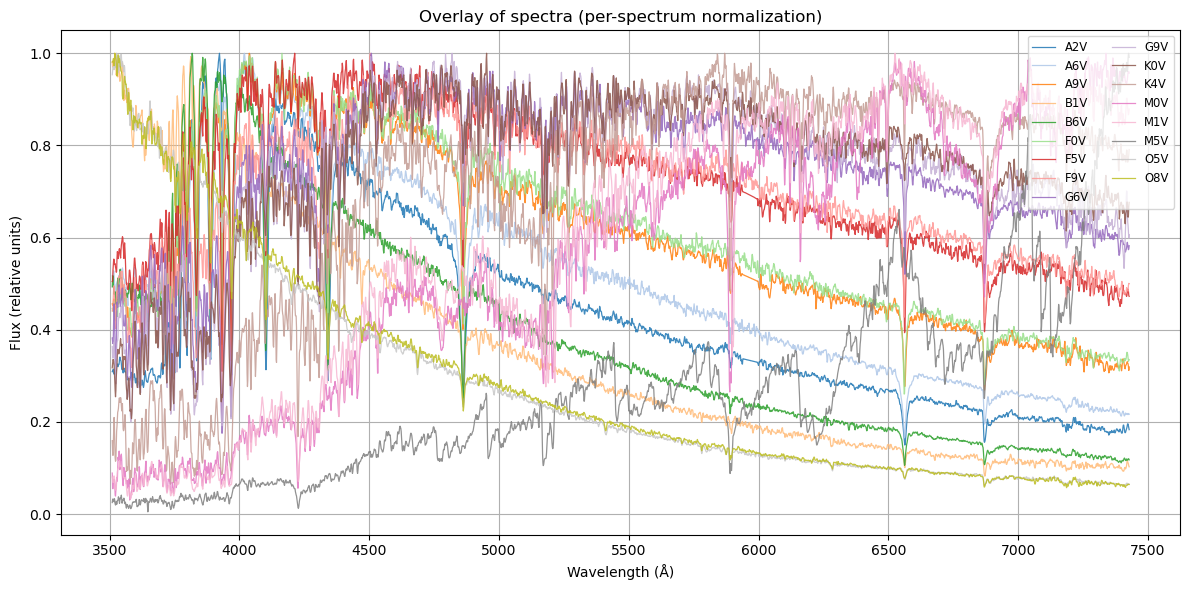

In [ ]:
# Overlay with per-spectrum scaling (preserve relative amplitudes when requested)
try:
    # Rebuild spectra dict in case it's not present in this scope
    spectra = {}
    for var in list(globals().keys()):
        if var.endswith('_wl'):
            base = var[:-3]
            wl = globals().get(var)
            flux = globals().get(base + '_flux')
            if wl is not None and flux is not None:
                spectra[base] = {'wl': wl, 'flux': flux}

    if len(spectra) == 0:
        print('No spectra available to plot. Make sure the .npz file was loaded successfully.')
    else:
        # Per-spectrum scaling: set scalars here (keys are spectrum names without _wl/_flux)
        # Example: scales = {'A2V': 1.0, 'G9V': 0.5}
        scales = {
            'A2V': 1.0,
            'A6V': 1.0,
            'A9V': 1.0,
            'B1V': 1.0,
            'B6V': 1.0,
            'F0V': 1.0,
            'F5V': 1.0,
            'F9V': 1.0,
            'G2V': 1.0,
            'G6V': 1.0,
            'G9V': 1.0,
            'K0V': 1.0,
            'K4V': 1.0,
            'M0V': 1.0,
            'M1V': 1.0,
            'M5V': 1.0,
            'O5V': 1.0,
            'O8V': 1.0,
        }

        # Decide normalization mode:
        # - If all scales == 1.0 -> use per-spectrum normalization (original behavior)
        # - If any scale != 1.0 -> compute global max after scaling and normalize by that (preserve relative amplitudes)
        use_global_norm = any(v != 1.0 for v in scales.values())

        global_max = 0.0
        if use_global_norm:
            for name, s in spectra.items():
                f = np.asarray(s['flux'], dtype=float) * scales.get(name, 1.0)
                if f.size == 0:
                    continue
                m = np.nanmax(np.abs(f))
                if np.isfinite(m) and m > global_max:
                    global_max = m

        import matplotlib.pyplot as plt
        cmap = plt.get_cmap('tab20')
        plt.figure(figsize=(12, 6))

        for i, name in enumerate(sorted(spectra.keys())):
            wl = spectra[name]['wl']
            flux = spectra[name]['flux']
            f = np.asarray(flux, dtype=float) * scales.get(name, 1.0)
            if f.size == 0:
                continue

            if use_global_norm:
                if global_max > 0:
                    f_plot = f / global_max
                else:
                    f_plot = f
            else:
                # per-spectrum normalization (divide by each spectrum's own max)
                maxval = np.nanmax(np.abs(f))
                if maxval == 0 or np.isnan(maxval):
                    f_plot = f
                else:
                    f_plot = f / maxval

            label = name
            if scales.get(name, 1.0) != 1.0:
                label = f"{name} (×{scales.get(name)})"

            plt.plot(wl, f_plot, label=label, color=cmap(i % 20), lw=0.9, alpha=0.85)

        plt.xlabel('Wavelength (Å)')
        plt.ylabel('Flux (relative units)')
        title_extra = ' (global normalization)' if use_global_norm else ' (per-spectrum normalization)'
        plt.title('Overlay of spectra' + title_extra)
        plt.grid(True)
        try:
            plt.legend(loc='upper right', fontsize='small', ncol=2)
        except Exception:
            plt.legend(fontsize='small')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print('Error plotting overlay with per-spectrum scaling:', e)

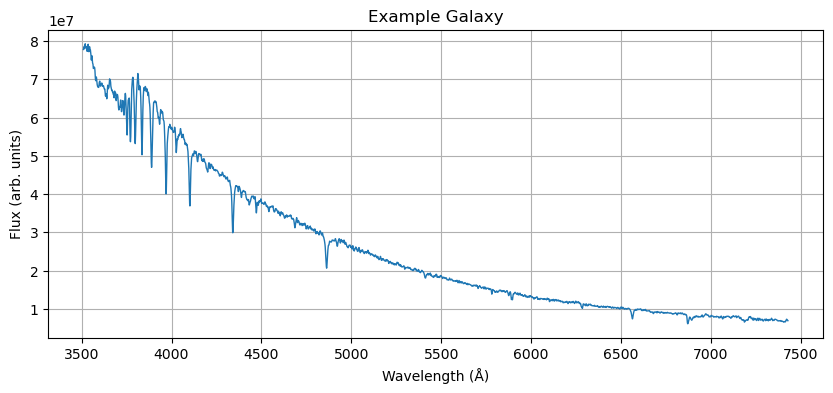

In [37]:
# Build class spectra and galaxy builder (per-class multipliers)
# Usage examples:
#   wl_o, flux_o = build_class_spectrum('O')         # O-class summed (no multiplier)
#   wl_gal, flux_gal = build_galaxy_spectrum({'O':50, 'G':1000})
try:
    # Ensure spectra dict exists (rebuild from globals if necessary)
    spectra = {}
    for var in list(globals().keys()):
        if var.endswith('_wl'):
            base = var[:-3]
            wl = globals().get(var)
            flux = globals().get(base + '_flux')
            if wl is not None and flux is not None:
                spectra[base] = {'wl': wl, 'flux': flux}

    # Define class membership for available spectra
    classes = {
        'O': ['O5V', 'O8V'],
        'B': ['B1V', 'B6V'],
        'A': ['A2V', 'A6V', 'A9V'],
        'F': ['F0V', 'F5V', 'F9V'],
        'G': ['G6V', 'G9V'],
        'K': ['K0V', 'K4V'],
        'M': ['M0V', 'M1V', 'M5V'],
    }

    import numpy as np
    import matplotlib.pyplot as plt

    # Cache for class spectra (summed without per-class multiplier)
    class_spectra = {}

    def build_class_spectrum(class_name, member_weights=None, ref_wl=None):
        """Return (wl, flux) for the summed class spectrum (no multiplier applied).

        - class_name: one-letter class (e.g. 'O', 'G').
        - member_weights: optional dict mapping member name -> weight applied before summing.
        - ref_wl: optional reference wavelength grid (1D array). If None, the first available member's wl is used.
        """
        cname = class_name.upper()
        if cname not in classes:
            raise ValueError(f"Unknown class '{class_name}'. Available: {list(classes.keys())}")

        members = [m for m in classes[cname] if m in spectra]
        if len(members) == 0:
            raise ValueError(f"No spectra available for class '{cname}'")

        # Use provided ref_wl or the first member's wl
        if ref_wl is None:
            ref_wl = np.asarray(spectra[members[0]]['wl'], dtype=float)
        else:
            ref_wl = np.asarray(ref_wl, dtype=float)

        summed = np.zeros_like(ref_wl, dtype=float)
        for m in members:
            wl_m = np.asarray(spectra[m]['wl'], dtype=float)
            flux_m = np.asarray(spectra[m]['flux'], dtype=float)
            # Interpolate flux to reference grid; out-of-range values -> 0
            f_interp = np.interp(ref_wl, wl_m, flux_m, left=0.0, right=0.0)
            weight = 1.0
            if member_weights and m in member_weights:
                weight = member_weights[m]
            summed += f_interp * weight

        # Cache using a tuple key (class, tuple(ref_wl) hash) - simple approach: store by class and ref_wl length
        class_spectra[cname] = (ref_wl, summed)
        return ref_wl, summed

    def build_galaxy_spectrum(class_multipliers, ref_wl=None, member_weights=None, res=5000):
        """Sum class spectra using per-class multipliers.

        - class_multipliers: dict mapping class letter -> multiplier (e.g. {'O':50, 'G':1000})
        - ref_wl: optional reference grid. If None, a common grid spanning all member ranges is created.
        - member_weights: optional dict mapping class -> {member: weight}
        - res: number of points for auto-generated reference grid when ref_wl is None.
        Returns (ref_wl, galaxy_flux)
        """
        # Determine which classes are requested and available
        selected = {c: v for c, v in class_multipliers.items() if c.upper() in classes and v != 0}
        if len(selected) == 0:
            raise ValueError('No valid classes provided in class_multipliers')

        # If no ref grid provided, find overall min/max wl across selected members
        if ref_wl is None:
            min_wl = np.inf
            max_wl = -np.inf
            for c in selected:
                for m in classes[c.upper()]:
                    if m in spectra:
                        wl_m = np.asarray(spectra[m]['wl'], dtype=float)
                        if wl_m.size:
                            min_wl = min(min_wl, wl_m.min())
                            max_wl = max(max_wl, wl_m.max())
            if not np.isfinite(min_wl) or not np.isfinite(max_wl) or min_wl >= max_wl:
                raise ValueError('Unable to determine wavelength range for selected classes')
            ref_wl = np.linspace(min_wl, max_wl, res)
        else:
            ref_wl = np.asarray(ref_wl, dtype=float)

        galaxy = np.zeros_like(ref_wl, dtype=float)
        for c, mult in selected.items():
            # build class spectrum (summed, unmultiplied)
            weights = None
            if member_weights and c in member_weights:
                weights = member_weights[c]
            try:
                _, class_flux = build_class_spectrum(c, member_weights=weights, ref_wl=ref_wl)
            except Exception as e:
                # skip missing class
                print(f"Skipping class {c}: {e}")
                continue
            galaxy += class_flux * mult

        return ref_wl, galaxy

    # Example: build a galaxy composed of 50 O stars and 1000 G stars, then plot
    galaxy_size = 10e10
    try:
        comps = {'O': 1 * galaxy_size , 'A': 5 * galaxy_size, 'B' : 14 * galaxy_size, 'F' : 69 * galaxy_size, 'G' : 150 * galaxy_size,
                 'K' : 250 * galaxy_size, 'M' : 420 * galaxy_size}
        wl_gal, flux_gal = build_galaxy_spectrum(comps)
        plt.figure(figsize=(10,4))
        plt.plot(wl_gal, flux_gal, lw=1.0)
        plt.xlabel('Wavelength (Å)')
        plt.ylabel('Flux (arb. units)')
        plt.title('Example Galaxy')
        plt.grid(True)
        plt.show()
    except Exception as e:
        print('Example galaxy build/plot skipped:', e)

except Exception as e:
    print('Error setting up galaxy builder:', e)